<a href="https://colab.research.google.com/github/navyasreeg2025-bot/eda-lab-experiment/blob/main/15_09_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

countries = ['India', 'United States', 'Germany', 'Brazil', 'Japan',
'Canada', 'Australia', 'France', 'South Africa', 'Nigeria']

categories = ['Data Science', 'Web Development', 'AI & ML', 'Cybersecurity']

feedback_words = ['excellent course', 'great instructor', 'very helpful content',
'too fast paced', 'loved the projects', 'needs more examples',
  'clear explanations', 'good support', 'boring lectures','amazing experience']

df = pd.DataFrame({
'Student_ID': range(1, n+1),
'Country': np.random.choice(countries, n),
'Course_Category': np.random.choice(categories, n),
'Age': np.random.randint(18, 45, n),
'Hours_Studied': np.round(np.random.uniform(1, 20, n), 1),
'Quizzes_Attempted': np.random.randint(0, 15, n),
'Assignments_Submitted': np.random.randint(0, 10, n),
'Final_Score': np.random.randint(35, 100, n),
'Feedback': np.random.choice(feedback_words, n)})

print(df.head())
print(df.shape)


   Student_ID    Country  Course_Category  Age  Hours_Studied  \
0           1  Australia  Web Development   44           16.3   
1           2     Brazil          AI & ML   27            6.4   
2           3     France          AI & ML   19            4.4   
3           4      Japan    Cybersecurity   43           15.3   
4           5  Australia    Cybersecurity   34           16.3   

   Quizzes_Attempted  Assignments_Submitted  Final_Score             Feedback  
0                 10                      9           83         good support  
1                  2                      5           83     excellent course  
2                 14                      3           54       too fast paced  
3                  8                      2           97  needs more examples  
4                  6                      3           95      boring lectures  
(200, 9)


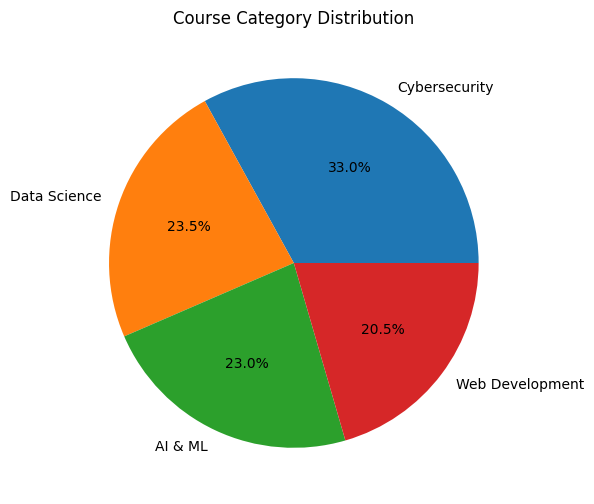

In [6]:
import matplotlib.pyplot as plt
counts=df['Course_Category'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts,labels=counts.index,autopct='%1.1f%%')
plt.title('Course Category Distribution')
plt.show()

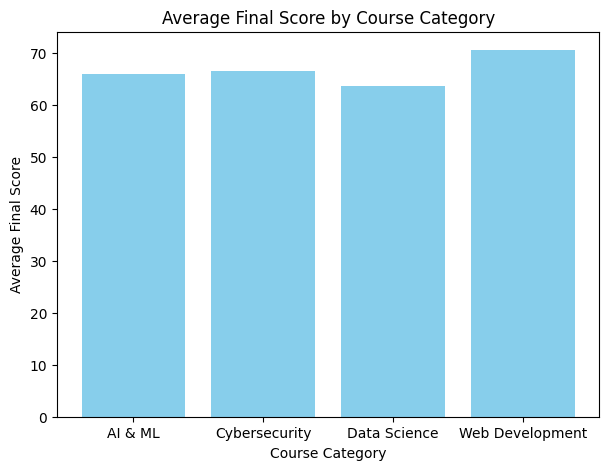

In [7]:
#Bar chart
avg_score=df.groupby('Course_Category')['Final_Score'].mean()
plt.figure(figsize=(7,5))
plt.bar(avg_score.index,avg_score.values,color='skyblue')
plt.title('Average Final Score by Course Category')
plt.xlabel('Course Category')
plt.ylabel('Average Final Score')
plt.show()

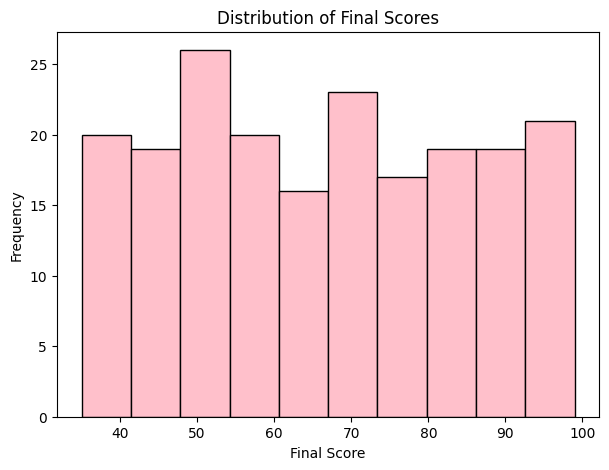

In [9]:
#Histogram
plt.figure(figsize=(7,5))
plt.hist(df['Final_Score'],bins=10,color='pink',edgecolor='black')
plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.show()

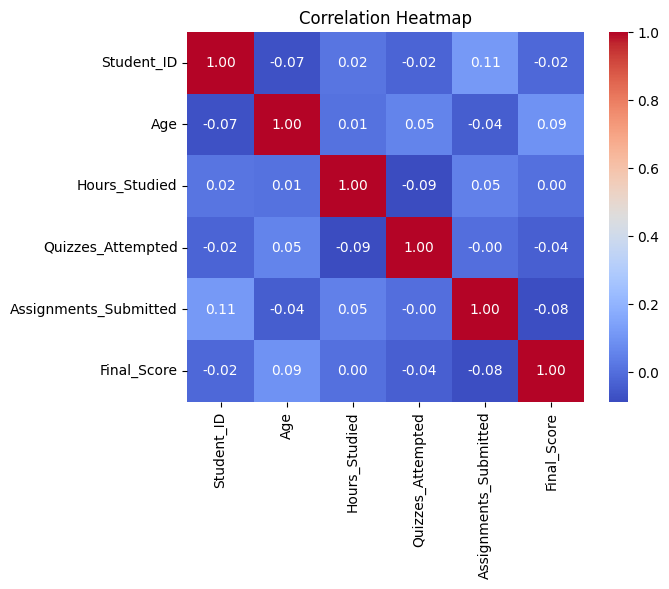

In [10]:
#heat map
import seaborn as sns
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
#Choropleth Map
import plotly.express as px
country_avg=df.groupby('Country')['Final_Score'].mean().reset_index()
fig=px.choropleth(country_avg,locations='Country',locationmode='country names',
                  color='Final_Score',color_continuous_scale='Viridis',
                  title='Average Final Score by Country')
fig.show()

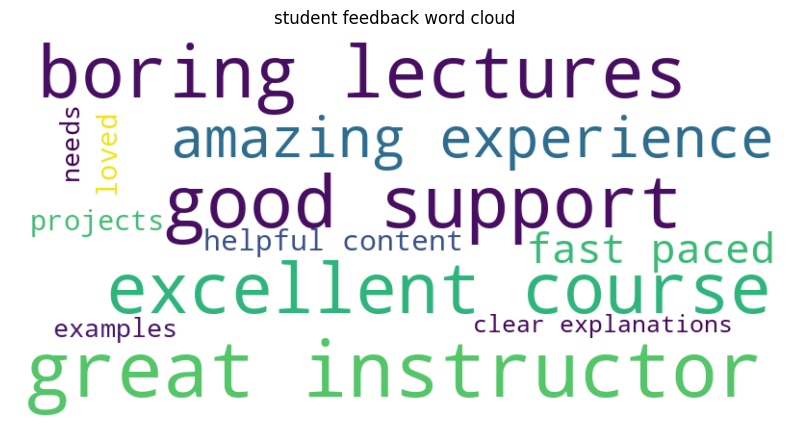

In [13]:
#word cloud
from wordcloud import WordCloud
text=" ".join(df['Feedback'])
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("student feedback word cloud")
plt.show()

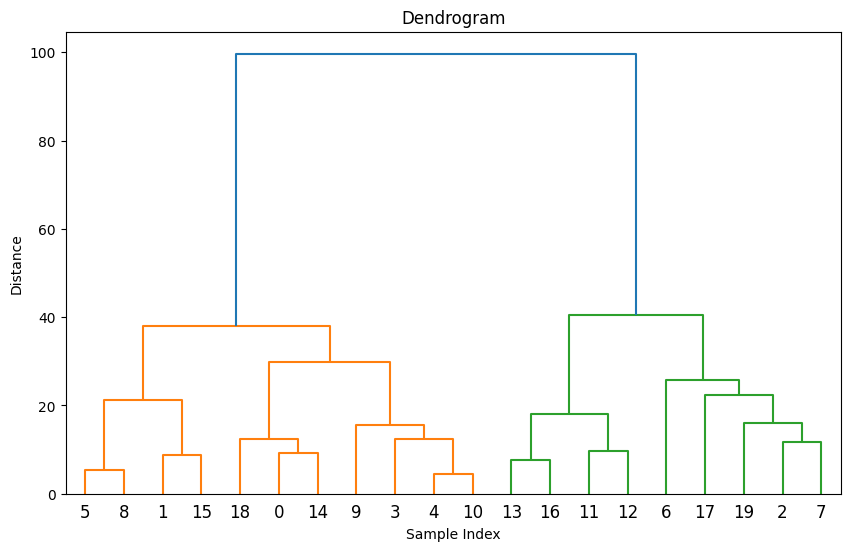

In [16]:
#Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
sample=df[['Age','Hours_Studied','Quizzes_Attempted','Assignments_Submitted','Final_Score']].head(20)
linked=linkage(sample,method='ward')
plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()


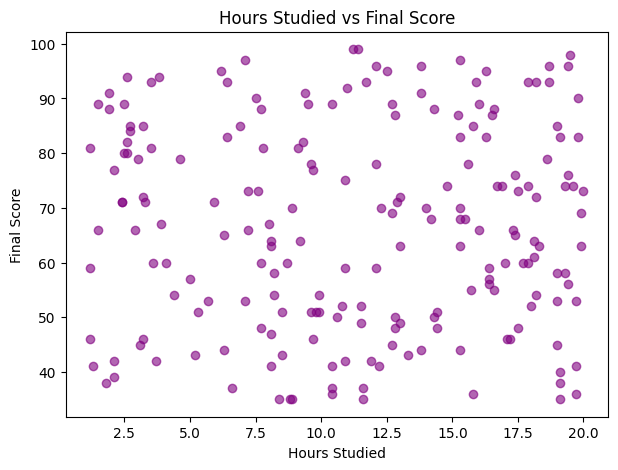

In [18]:
#scatter plot
plt.figure(figsize=(7,5))
plt.scatter(df['Hours_Studied'],df['Final_Score'],alpha=0.6,color='purple')
plt.title('Hours Studied vs Final Score')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.show()


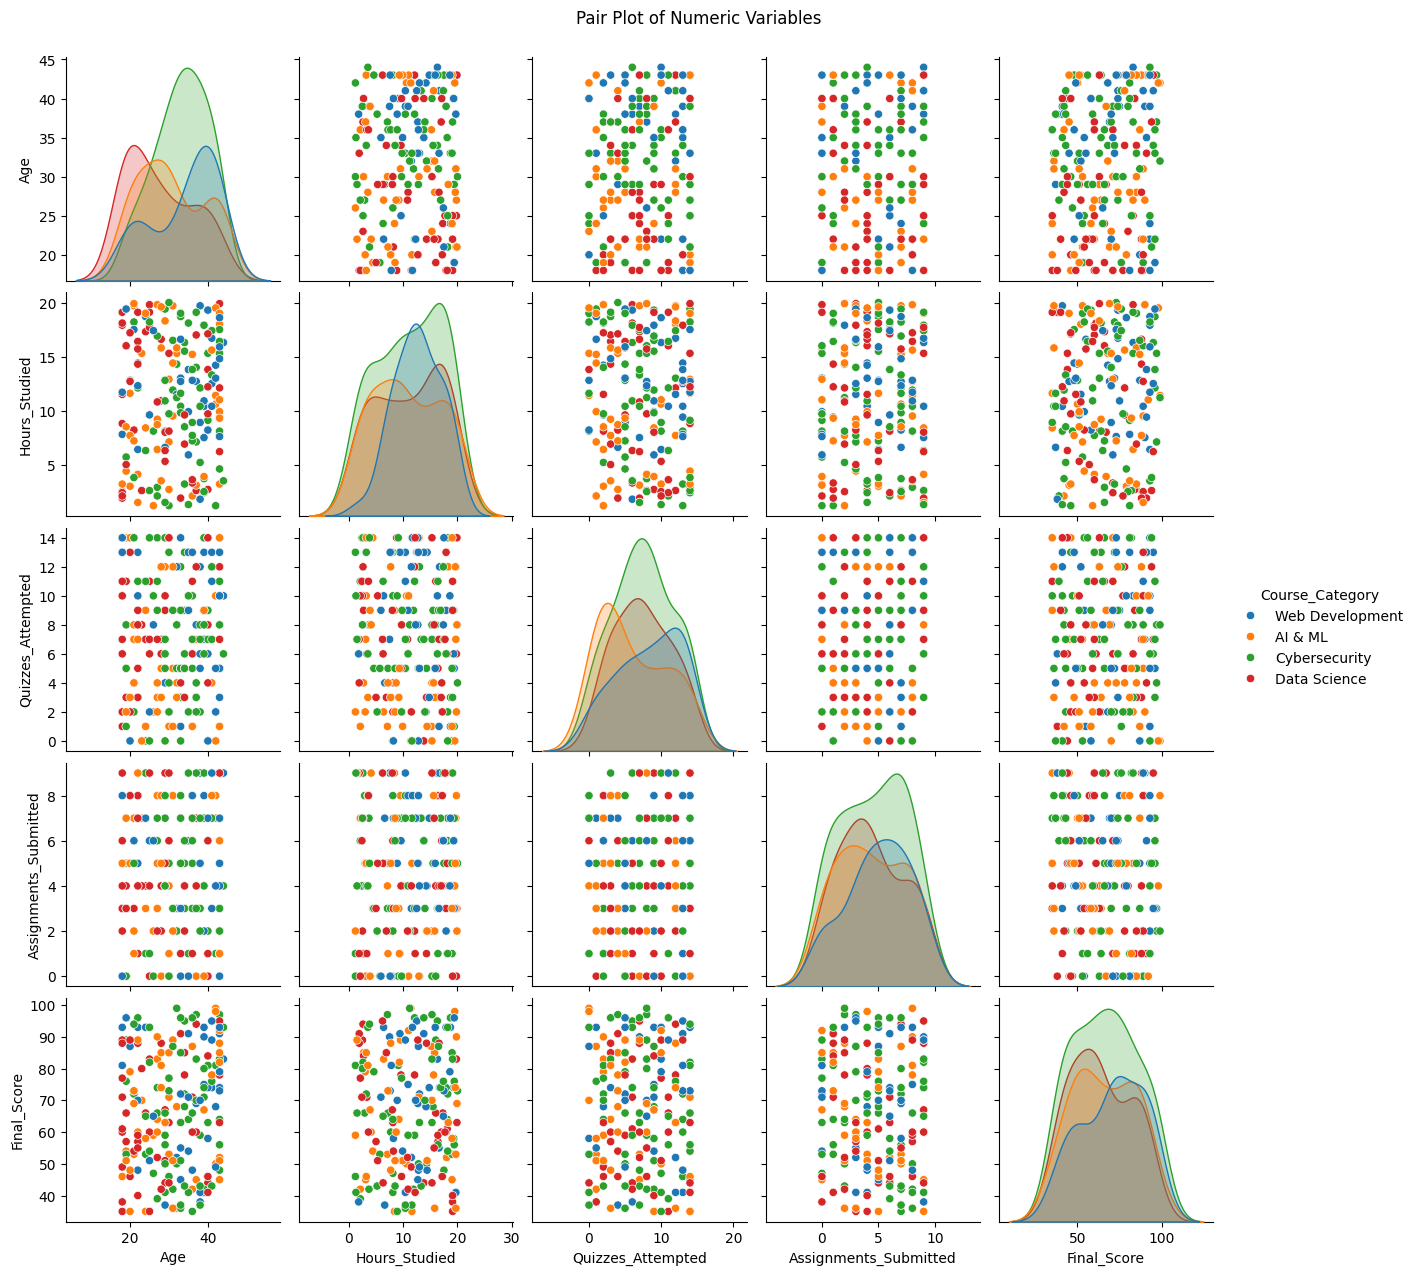

In [19]:
#pair plot
num_cols=['Age','Hours_Studied','Quizzes_Attempted','Assignments_Submitted','Final_Score']
sns.pairplot(df[num_cols+['Course_Category']],hue='Course_Category')
plt.suptitle('Pair Plot of Numeric Variables',y=1.02)
plt.show()

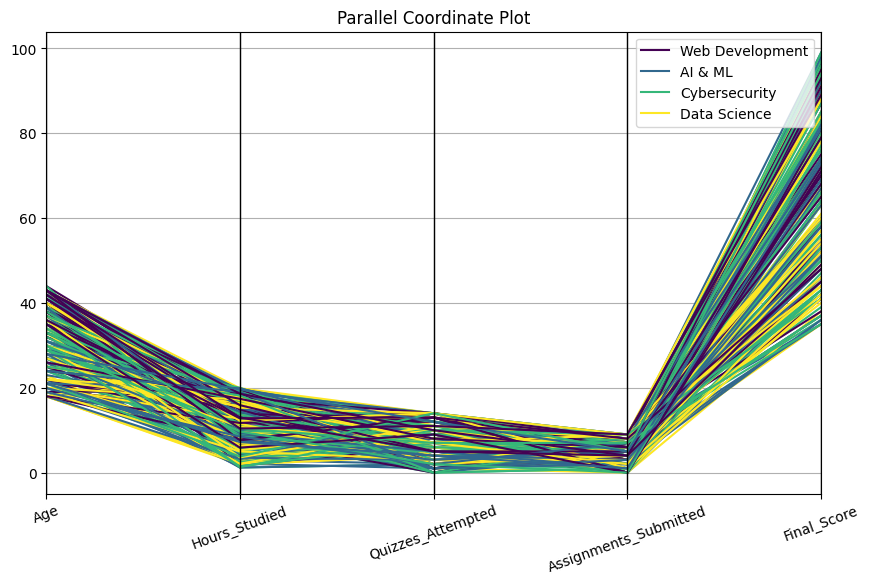

In [20]:
#parallel coordinate plot
from pandas.plotting import parallel_coordinates
plt.figure(figsize=(10,6))
parallel_coordinates(df[num_cols+['Course_Category']],'Course_Category',colormap='viridis')
plt.title('Parallel Coordinate Plot')
plt.xticks(rotation=20)
plt.show()

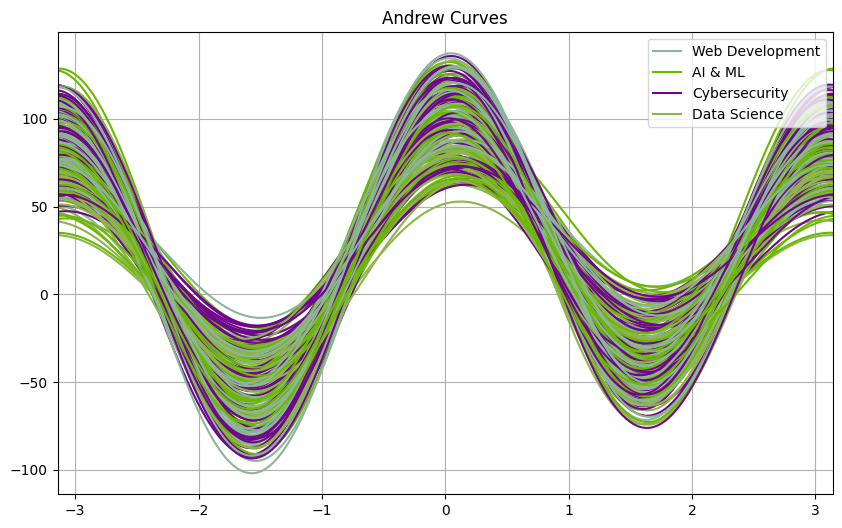

In [21]:
#Andrew curves
from pandas.plotting import andrews_curves
plt.figure(figsize=(10,6))
andrews_curves(df[num_cols+['Course_Category']],'Course_Category')
plt.title('Andrew Curves')
plt.show()